# General Explanation of the Notebook

This notebook aims to analyze stock price predictions using various machine learning models such as Random Forest, XGBoost, and SVR.

### Main Objectives:
1. Train and evaluate predictive models based on metrics like RMSE, MAE, and MASE for validation and test datasets.
2. Optimize model performance by tuning hyperparameters using RandomizedSearchCV.
3. Implement Monte Carlo simulations to forecast scenarios of volatility and growth based on predictions from fine-tuned models.
4. Visualize and compare results, highlighting the impact of hyperparameters and the accuracy of predictions.
5. Identify the best-performing model for future applications.

### Practical Applications:
This study can be applied in financial environments to:
- Predict market movements and assist in investment decision-making.
- Analyze the impact of different economic scenarios using Monte Carlo simulations.
- Select the most effective predictive models for investment strategies based on historical data.

All steps have been implemented to allow future adjustments, performance analysis, and integration with broader financial systems.

### Importing necessary libraries

In [40]:
# Data manipulation and analysis
import pandas as pd  

# Data visualization
import matplotlib.pyplot as plt  
import seaborn as sns  

# Numerical computations
import numpy as np  

# Machine learning models
from xgboost import XGBRegressor  # Extreme Gradient Boosting
from sklearn.svm import SVR  # Support Vector Regression
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks

# Model evaluation metrics
from sklearn.metrics import mean_absolute_error  # Mean Absolute Error (MAE)

# Cross-validation for time series data
from sklearn.model_selection import TimeSeriesSplit  

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV  

# Handling missing values
from sklearn.impute import SimpleImputer  

# Working with abstract syntax trees (e.g., parsing strings into Python objects)
import ast 

### Data quality asessment and data cleaning

In [3]:
# Loading the dataset and parsing the "Date" column as datetime
data = pd.read_csv("sp500_stocks.csv", parse_dates=["Date"])

In [4]:
# Create a list of columns to analyze, excluding "Symbol" and "Date"
colunas = [col for col in data.columns if col not in ["Symbol", "Date"]]

# Filter valid companies: Exclude companies where all values in the selected columns are NaN
empresas_validas = data.groupby("Symbol").filter(
    lambda x: not x[colunas].isna().all().all()
)

# Uncomment the line below to save the filtered data to a CSV file
# empresas_validas.to_csv("sp500_filtered.csv", index=False)

In [5]:
# Load the filtered dataset from the "sp500_filtered.csv" file
data_filtered = pd.read_csv("sp500_filtered.csv")

In [6]:
# Create a dictionary to store DataFrames for each company
empresas_dataframes = {}

# Iterate through each unique company symbol in the filtered dataset
for symbol in data_filtered["Symbol"].unique():
    # Filter the data for the current company
    df_empresa = data_filtered[data_filtered["Symbol"] == symbol]
    # Store the company's DataFrame in the dictionary with the symbol as the key
    empresas_dataframes[symbol] = df_empresa

### Data pre-processing

Lagged Features

	•	Previous days values to predict future prices.

 Moving Averages

	•	Smooth data and trends over a window 

Volatility Indicators

	•	Standard deviation or percentage changes

Rate of Change (Momentum)

	•	Momentum of price movements

Relative Strength Index (RSI)

	•	Overbought or oversold conditions

In [7]:
def preprocess_dataframe(df):
    # Ensure we are working with a copy of the DataFrame
    df = df.copy()
    
    # Create lag columns for the "Close" price
    for lag in [1, 3, 7]:
        df.loc[:, f"Close_lag_{lag}"] = df["Close"].shift(lag)
    
    # Calculate moving averages and volatility
    df.loc[:, "MA_5"] = df["Close"].rolling(window=5).mean()
    df.loc[:, "MA_10"] = df["Close"].rolling(window=10).mean()
    df.loc[:, "Volatility_5"] = df["Close"].rolling(window=5).std()

    # Calculate the Rate of Change (ROC)
    df.loc[:, "ROC_5"] = df["Close"].pct_change(periods=5)
    
    # Calculate the Relative Strength Index (RSI)
    def calculate_rsi(data, window=14):
        # Calculate price changes
        delta = data["Close"].diff()
        # Calculate average gains and losses over the window
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        # Compute the relative strength (RS) and RSI
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    df.loc[:, "RSI"] = calculate_rsi(df)
    
    # Create a "Target" column by shifting the "Close" price by -1 (next day's price)
    df.loc[:, "Target"] = df["Close"].shift(-1)
    
    # Fill missing values
    df.ffill(inplace=True)  # Forward fill missing values
    df.bfill(inplace=True)  # Backward fill missing values
    
    return df

In [8]:
# Function to handle invalid values in a dataset
def clean_data(X, y=None):
    # Impute missing values in X using the mean
    imputer = SimpleImputer(strategy="mean")  # Replace NaN with the mean of the column
    X_cleaned = imputer.fit_transform(X)
    
    if y is not None:
        # Handle missing or infinite values in y
        y_cleaned = np.nan_to_num(
            y, 
            nan=np.mean(y),          # Replace NaN with the mean of y
            posinf=np.mean(y),       # Replace positive infinity with the mean of y
            neginf=np.mean(y)        # Replace negative infinity with the mean of y
        )
        return X_cleaned, y_cleaned
    
    return X_cleaned

In [9]:
# Apply the preprocessing function to each company's DataFrame
empresas_dataframes = {
    symbol: preprocess_dataframe(df)  # Preprocess the DataFrame for the company
    for symbol, df in empresas_dataframes.items()  # Iterate through each company in the dictionary
}

### Exploratory Data Analysis

In [10]:
# Combine all individual DataFrames into a single DataFrame
# Each DataFrame is augmented with a "Symbol" column to indicate the company it belongs to
combined_df = pd.concat(
    [df.assign(Symbol=symbol) for symbol, df in empresas_dataframes.items()],
    ignore_index=True  # Reset the index in the combined DataFrame
)

# Print the shape of the combined DataFrame to check its size
print(combined_df.shape)

(646548, 17)


In [11]:
# Display general statistics for the entire dataset (across all companies)
print(combined_df.describe())

           Adj Close          Close           High            Low  \
count  646548.000000  646548.000000  646548.000000  646548.000000   
mean       97.489078     105.360881     106.582751     104.155408   
std       193.708125     194.740201     196.738691     192.597367   
min         0.203593       0.222000       0.226250       0.216250   
25%        26.229220      31.170000      32.020000      30.799999   
50%        51.176895      60.130001      61.279999      59.480000   
75%       100.794491     112.709999     113.779999     111.570000   
max      5300.339844    5300.339844    5337.200195    5260.000000   

                Open        Volume    Close_lag_1    Close_lag_3  \
count  646548.000000  6.465480e+05  646548.000000  646548.000000   
mean      105.370979  1.089498e+07     105.307099     105.198871   
std       194.662792  5.389246e+07     194.572691     194.228216   
min         0.218000  0.000000e+00       0.222000       0.222000   
25%        31.680000  9.664000e+05    

In [12]:
# Check for missing data across all columns in the combined dataset
# This will return the total count of missing values (NaN) for each column
print(combined_df.isnull().sum())

Date            0
Symbol          0
Adj Close       0
Close           0
High            0
Low             0
Open            0
Volume          0
Close_lag_1     0
Close_lag_3     0
Close_lag_7     0
MA_5            0
MA_10           0
Volatility_5    0
ROC_5           0
RSI             0
Target          0
dtype: int64


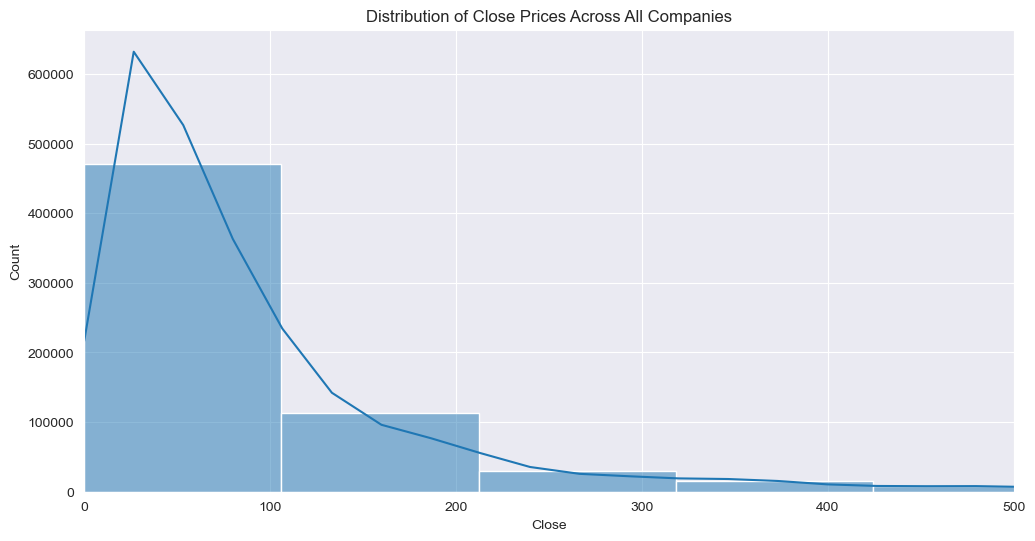

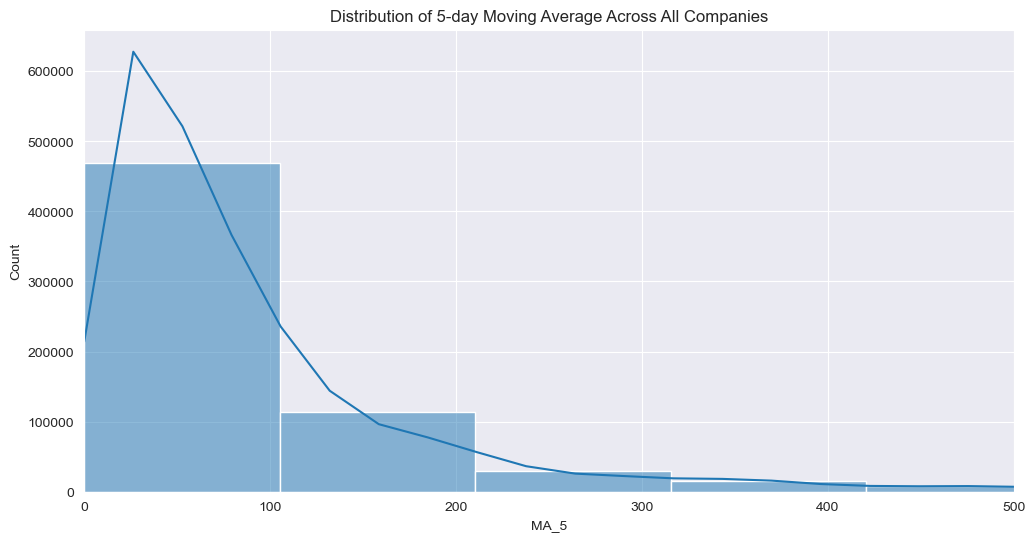

In [14]:
# Distribution of 'Close' prices for all companies
plt.figure(figsize=(12, 6))  # Set the figure size
sns.histplot(combined_df['Close'], kde=True, bins=50)  # Plot a histogram with a KDE curve
plt.title('Distribution of Close Prices Across All Companies')  # Add a title to the plot
plt.xlim(0, 500)  # Limit the x-axis range for better visualization
plt.show()  # Display the plot

# Distribution of moving averages across all companies
plt.figure(figsize=(12, 6))  # Set the figure size
sns.histplot(combined_df['MA_5'], kde=True, bins=50)  # Plot a histogram with a KDE curve for MA_5
plt.title('Distribution of 5-day Moving Average Across All Companies')  # Add a title to the plot
plt.xlim(0, 500)  # Limit the x-axis range for better visualization
plt.show()  # Display the plot

# Additional indicators can be plotted in the same way, such as RSI, ROC, or volatility

The first chart displays the distribution of 'Close' prices across all companies.
The majority of the prices are concentrated below $100, indicating that most companies have relatively low closing prices.
The x-axis is limited to a range of 0 to 500 to exclude extreme outliers and focus on the main distribution.
The KDE (Kernel Density Estimate) curve provides a smooth visualization of the data distribution.

The second chart shows the distribution of the 5-day moving averages (MA_5) for all companies.
Similar to the 'Close' prices, the MA_5 values are mostly concentrated below $100.
The KDE curve highlights the trend of the moving averages, which generally follow the same pattern as the 'Close' prices.
The x-axis range is also set between 0 and 500 to align with the 'Close' price distribution and avoid outliers.

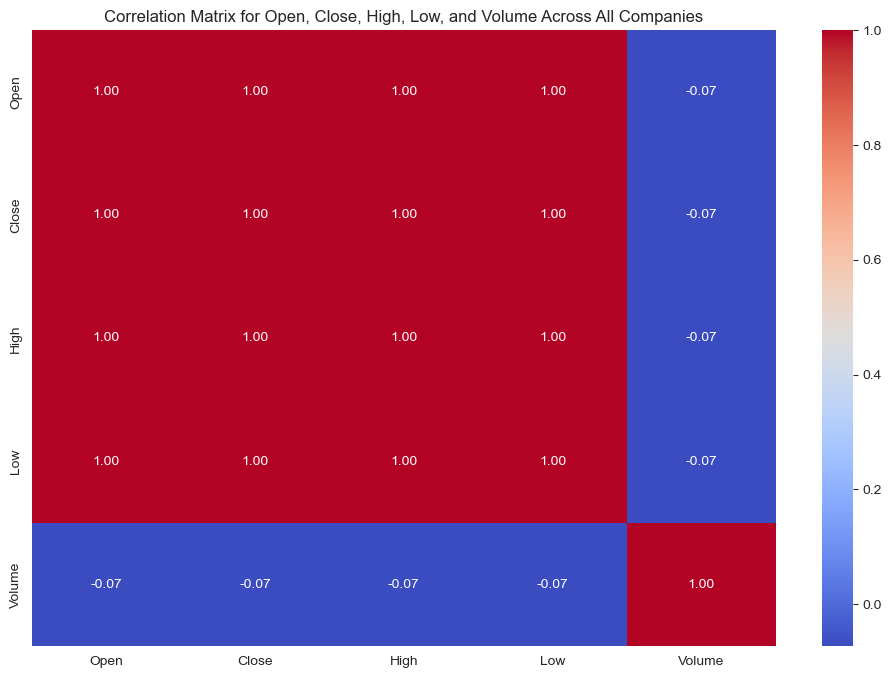

In [15]:
# Select only the relevant columns for correlation analysis
# The chosen columns are 'Open', 'Close', 'High', 'Low', and 'Volume', as they are directly related to stock prices.
relevant_columns = ['Open', 'Close', 'High', 'Low', 'Volume']
relevant_df = combined_df[relevant_columns]

# Calculate the correlation matrix
# This will compute pairwise Pearson correlation coefficients between the selected columns.
corr_matrix = relevant_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))  # Set the figure size for better readability
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")  # Create a heatmap with annotations
plt.title('Correlation Matrix for Open, Close, High, Low, and Volume Across All Companies')  # Add a title
plt.show()  # Display the heatmap

The heatmap visualizes the correlation matrix for the selected columns: 
'Open', 'Close', 'High', 'Low', and 'Volume'.
Strong positive correlations (values close to 1) are represented in red, while weak or negative correlations are in blue.
Observations:
- The 'Open', 'Close', 'High', and 'Low' prices have a perfect correlation (1.00) with each other. This is expected since these metrics are tightly related in daily stock data.
- 'Volume' has a very weak negative correlation (~-0.07) with the price-related columns, suggesting that trading volume and prices are not strongly related in this dataset.
- The diagonal values are all 1.00, as each feature is perfectly correlated with itself.

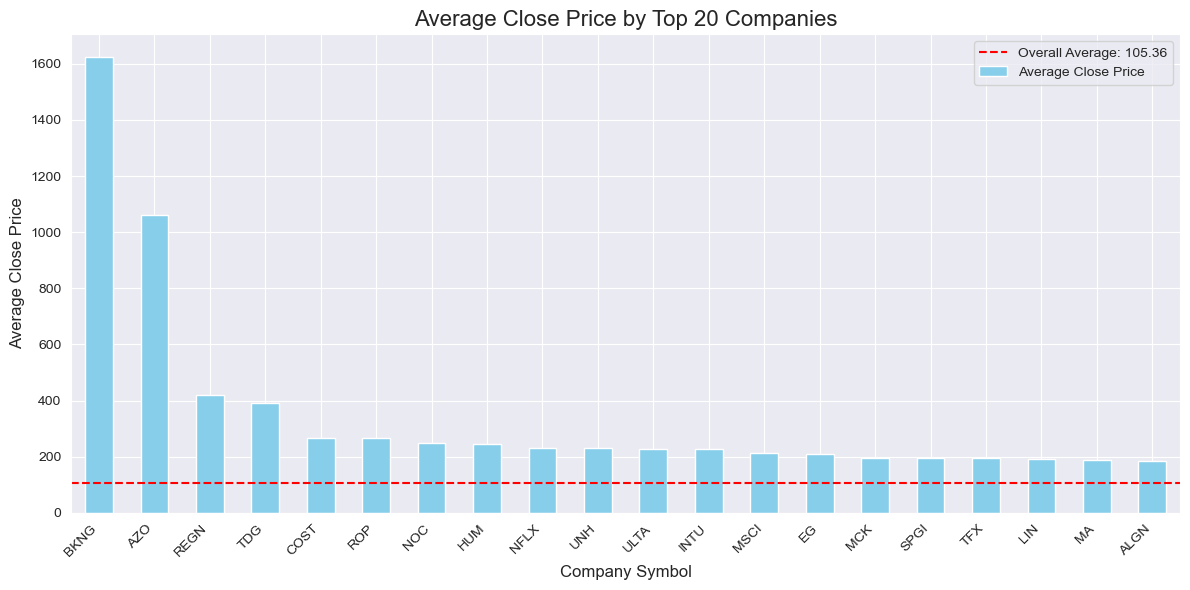

In [21]:
# Calculate and plot the mean 'Close' price by company
plt.figure(figsize=(12, 6))  # Set the figure size for better visualization

# Group the data by 'Symbol' (company) and calculate the average 'Close' price for each company
avg_close_by_company = combined_df.groupby('Symbol')['Close'].mean().sort_values(ascending=False)

# Plot only the top 20 companies for better readability
avg_close_by_company.head(20).plot(kind='bar', color='skyblue', label='Average Close Price')  # Use a bar chart and set a color for clarity

# Add a horizontal line indicating the overall average close price across all companies
overall_avg = avg_close_by_company.mean()
plt.axhline(y=overall_avg, color='red', linestyle='--', label=f'Overall Average: {overall_avg:.2f}')

# Add titles and labels
plt.title('Average Close Price by Top 20 Companies', fontsize=16)  # Add a title
plt.xlabel('Company Symbol', fontsize=12)  # Label the x-axis
plt.ylabel('Average Close Price', fontsize=12)  # Label the y-axis

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')  # Rotate labels and align them to the right

# Add a legend for clarity
plt.legend(fontsize=10)

# Adjust layout to fit everything nicely
plt.tight_layout()

# Display the chart
plt.show()

The bar chart displays the average 'Close' prices for the top 20 companies with the highest values.
Observations:
- BKNG (Booking Holdings) has the highest average close price, significantly surpassing other companies.
- AZO (AutoZone) and REGN (Regeneron Pharmaceuticals) follow in the second and third positions.
- The red dashed line represents the overall average close price across all companies ($105.36 in this case).
- Most companies in the top 20 have prices well above the overall average, but the difference is notable.

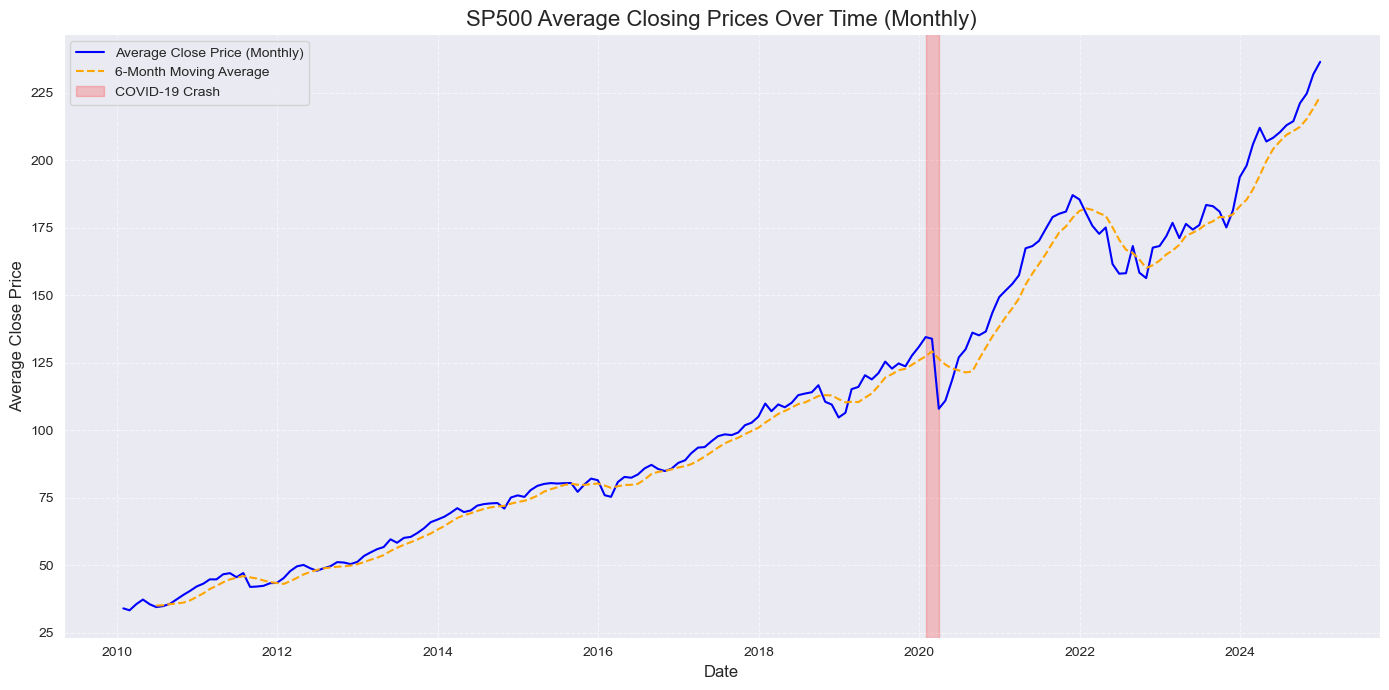

In [24]:
# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format for time-based operations

# Calculate the monthly average 'Close' price
monthly_avg = data.resample('M', on='Date')['Close'].mean()  # Resample data to monthly frequency and compute the mean 'Close' price

# Calculate a 6-month moving average for smoother trends
monthly_avg_smooth = monthly_avg.rolling(window=6).mean()  # 6-month moving average

# Plot the SP500 average closing prices over time (monthly)
plt.figure(figsize=(14, 7))  # Set the figure size for better visualization

# Plot the monthly average close price
plt.plot(monthly_avg.index, monthly_avg, label='Average Close Price (Monthly)', color='blue')

# Plot the 6-month moving average
plt.plot(monthly_avg.index, monthly_avg_smooth, label='6-Month Moving Average', color='orange', linestyle='--')

# Highlight specific events (e.g., COVID-19 crash in early 2020)
plt.axvspan('2020-02', '2020-04', color='red', alpha=0.2, label='COVID-19 Crash')

# Add titles and labels
plt.title('SP500 Average Closing Prices Over Time (Monthly)', fontsize=16)  # Add a title
plt.xlabel('Date', fontsize=12)  # Label the x-axis
plt.ylabel('Average Close Price', fontsize=12)  # Label the y-axis

# Add gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Add a legend for clarity
plt.legend(fontsize=10)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the chart
plt.show()

The chart displays the monthly average closing prices of the S&P 500 over time, with a 6-month moving average for trend analysis.
Observations:
- There is a clear long-term upward trend in the average closing prices of the S&P 500.
- The shaded red region highlights the COVID-19 market crash (February to April 2020), showing a sharp decline followed by a recovery.
- The 6-month moving average (orange dashed line) smooths out fluctuations and provides a clearer view of macro trends.
- Recent years show a significant acceleration in the upward trend, reflecting strong market performance.

Features included:
- A 6-month moving average for smoother trend observation.
- Highlighting of a significant market event (COVID-19 crash) using a shaded region.
- Gridlines and a clean layout for better readability.
- Legends and labels for clarity and context.

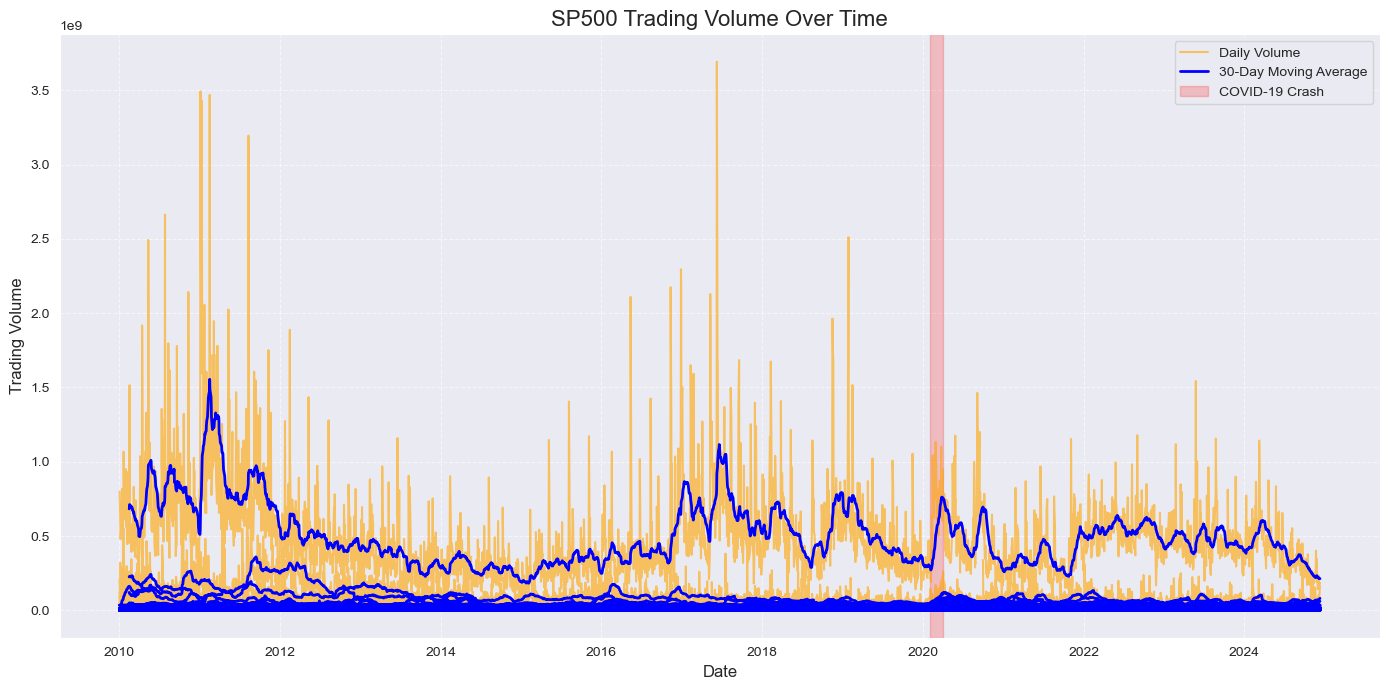

In [25]:
# Calculate a 30-day moving average for trading volume
data['Volume_MA'] = data['Volume'].rolling(window=30).mean()  # 30-day moving average

# Plot the SP500 trading volume over time with moving average
plt.figure(figsize=(14, 7))  # Set a larger figure size
plt.plot(data['Date'], data['Volume'], color='orange', label='Daily Volume', alpha=0.6)  # Original volume with transparency
plt.plot(data['Date'], data['Volume_MA'], color='blue', label='30-Day Moving Average', linewidth=2)  # Smoothed trend

# Highlight specific events (e.g., COVID-19 crash)
plt.axvspan('2020-02', '2020-04', color='red', alpha=0.2, label='COVID-19 Crash')

# Add titles and labels
plt.title('SP500 Trading Volume Over Time', fontsize=16)  # Add a descriptive title
plt.xlabel('Date', fontsize=12)  # Label the x-axis
plt.ylabel('Trading Volume', fontsize=12)  # Label the y-axis

# Add gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Add a legend for clarity
plt.legend(fontsize=10)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the chart
plt.show()

The chart illustrates the daily trading volume of the S&P 500 over time, complemented by a 30-day moving average.
Observations:
- The raw volume data (orange line) shows high daily fluctuations, with notable peaks during major market events.
- The 30-day moving average (blue line) smooths out these fluctuations, highlighting underlying trends in trading volume.
- The highlighted red region represents the COVID-19 market crash (February to April 2020), which shows a significant surge in trading activity.
- After the early 2010s, trading volume appears to stabilize, with occasional spikes reflecting increased market activity.

Features:
- Daily volume is visualized alongside a smoothed 30-day moving average for better trend detection.
- Specific events, such as the COVID-19 crash, are highlighted for context.
- Gridlines and a clean layout improve readability and analysis.

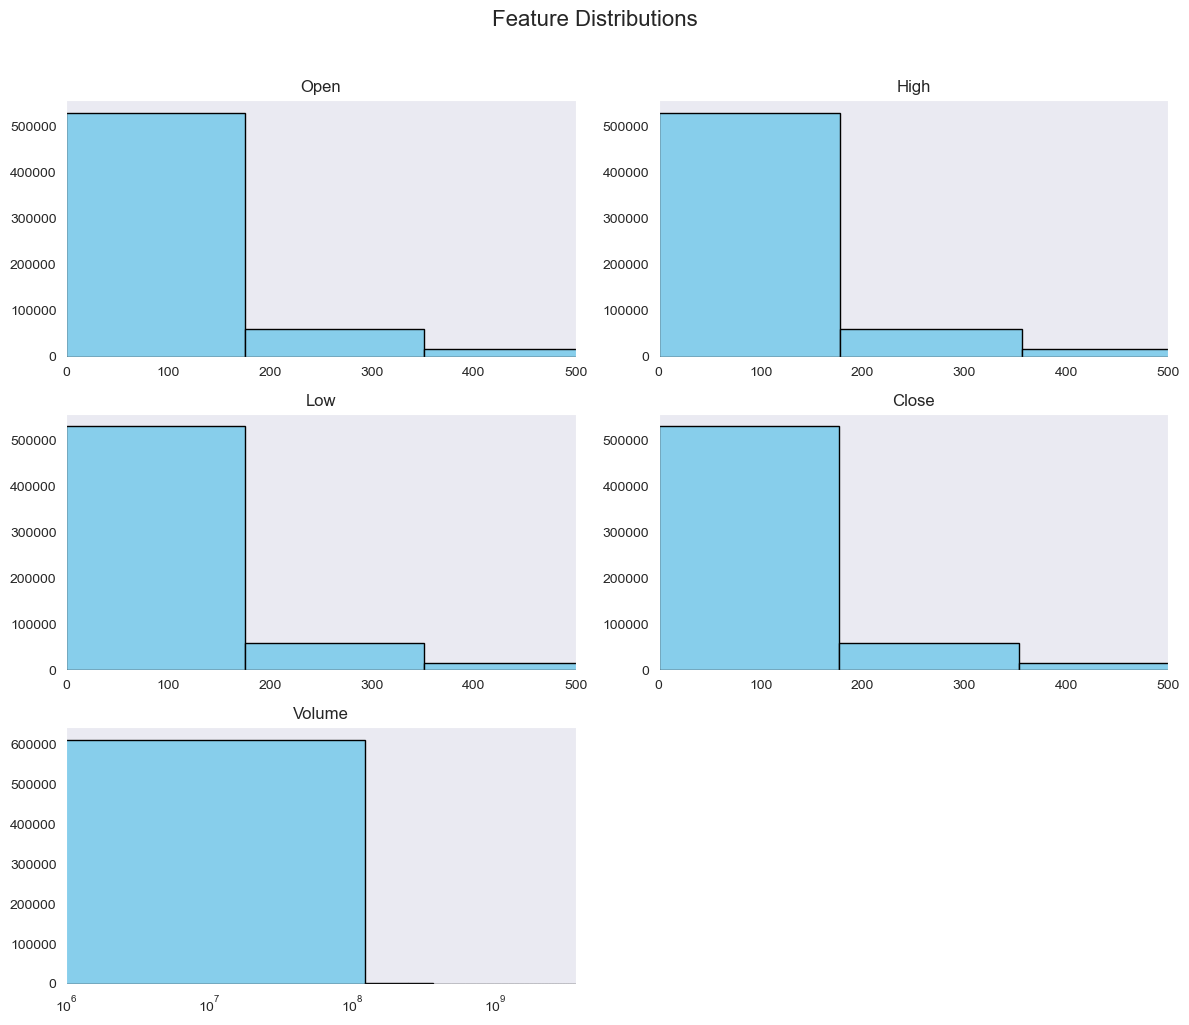

In [27]:
# Plot histograms for selected features to visualize their distributions
axes = data[['Open', 'High', 'Low', 'Close', 'Volume']].hist(
    figsize=(12, 10),  # Adjusted figure size for better readability
    bins=30,  # Number of bins for the histograms
    color='skyblue',  # Set a consistent color for all histograms
    edgecolor='black'  # Add edges to bins for clarity
)

# Set limits and style for individual axes
for ax in axes.flatten():
    # Adjust x-axis limits for most features
    if ax.get_title() in ['Open', 'High', 'Low', 'Close']:
        ax.set_xlim(0, 500)  # Limit x-axis to focus on relevant range
    elif ax.get_title() == 'Volume':  # Adjust Volume histogram separately
        ax.set_xscale('log')  # Apply logarithmic scale for better visualization
        ax.set_xlim(1e6, data['Volume'].max())  # Adjust x-axis range for Volume
    ax.grid(False)  # Disable grid for cleaner plots
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)  # Increase font size for x-axis labels
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)  # Increase font size for y-axis labels

# Add a central title for all subplots
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)  # Adjust position and size

# Adjust layout to avoid overlapping
plt.tight_layout()

# Display the histograms
plt.show()

The histograms display the distributions of key features: 'Open', 'High', 'Low', 'Close', and 'Volume'.
Observations:
- The distributions for 'Open', 'High', 'Low', and 'Close' are highly concentrated below 100, with very few data points exceeding 200.
- The trading volume ('Volume') spans a much wider range, as indicated by the use of a logarithmic scale.
- The logarithmic scale for 'Volume' highlights that most data points are concentrated in lower ranges, with a few outliers showing significantly higher values.

Features:
- A logarithmic scale was applied to the 'Volume' histogram to improve visualization of its wide range.
- The x-axis for 'Open', 'High', 'Low', and 'Close' was limited to a range of 0 to 500 for better focus.
- Consistent styling was applied across all histograms, including a central title, uniform colors, and clear labels.

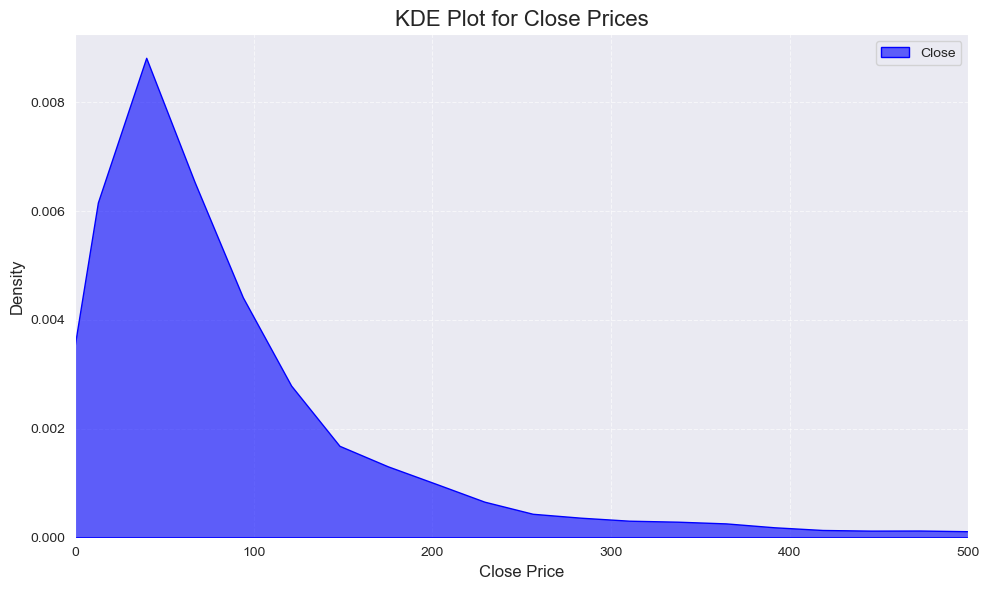

In [28]:
# Plot a Kernel Density Estimate (KDE) for the 'Close' prices
plt.figure(figsize=(10, 6))  # Set a larger figure size for better readability
sns.kdeplot(
    data['Close'], 
    label='Close', 
    fill=True,  # Fill the area under the curve
    color='blue',  # Set a consistent color for the KDE plot
    alpha=0.6  # Set transparency for the fill
)

# Add a title and axis labels
plt.title('KDE Plot for Close Prices', fontsize=16)  # Add a descriptive title
plt.xlabel('Close Price', fontsize=12)  # Label the x-axis
plt.ylabel('Density', fontsize=12)  # Label the y-axis

# Add a legend to clarify the plotted curve
plt.legend(fontsize=10)

# Limit the x-axis range for better focus
plt.xlim(0, 500)

# Add gridlines for better visualization
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the KDE plot
plt.show()

The KDE plot visualizes the distribution of the 'Close' prices.
Observations:
- The majority of the 'Close' prices are concentrated below $100, with a steep decline in density beyond this range.
- A long tail extends towards higher prices, indicating that a few stocks have significantly higher closing prices.
- The smooth curve highlights the general trend in the data, eliminating noise caused by outliers or sparse values.

Features:
- The x-axis is limited to a range of 0 to 500 for better focus on the majority of data points.
- The area under the curve is filled for improved visual impact.
- Gridlines and clear labels make the plot easy to interpret.


#### In this section, the data is divided into training, validation, and test sets. 

### Division of Data:
- **Training set**: Used to train the models.
- **Validation set**: Used to tune the hyperparameters and evaluate performance during model development.
- **Test set**: Used to evaluate the final performance of the model on unseen data.

### Choice of Metrics:
The following metrics are used to evaluate model performance:

- **MAE (Mean Absolute Error)**: Indicates the average absolute difference between predicted and actual values, offering a straightforward interpretation.
- **MASE (Mean Absolute Scaled Error)**: Allows comparison across different time series by scaling errors relative to a naive forecast. This metric is especially useful when dealing with time-series data.

In [29]:
def data_split(data):
    # Define the training data: From 2010-01-01 to 2022-06-30
    train_data = data[(data['Date'] >= '2010-01-01') & (data['Date'] < '2022-07-01')]
    
    # Define the validation data: From 2022-07-01 to 2023-12-31
    val_data = data[(data['Date'] >= '2022-07-01') & (data['Date'] < '2024-01-01')]
    
    # Define the test data: From 2024-01-01 onwards
    test_data = data[data['Date'] >= '2024-01-01']
    
    # Separate features (X) and target (y) for training
    X_train = train_data.drop(['Date', 'Symbol', 'Target'], axis=1)  # Drop unnecessary columns
    y_train = train_data['Target']  # Extract the target column
    
    # Separate features (X) and target (y) for validation
    X_val = val_data.drop(['Date', 'Symbol', 'Target'], axis=1)  # Drop unnecessary columns
    y_val = val_data['Target']  # Extract the target column
    
    # Separate features (X) and target (y) for testing
    X_test = test_data.drop(['Date', 'Symbol', 'Target'], axis=1)  # Drop unnecessary columns
    y_test = test_data['Target']  # Extract the target column
    
    return X_train, y_train, X_test, y_test, X_val, y_val

In [30]:
# Calculates the Mean Absolute Scaled Error (MASE) for evaluating forecast accuracy.
def calculate_mase(y_true, y_pred):
    # Convert inputs to numpy arrays for easier manipulation
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate the absolute errors of the predictions
    absolute_error = np.abs(y_true - y_pred)
    
    # Calculate the naive forecast error (difference between consecutive true values)
    naive_error = np.abs(np.diff(y_true))
    
    # Calculate the mean absolute naive error
    mean_naive_error = np.mean(naive_error)
    
    # Handle the case where the mean naive error is zero to avoid division by zero
    if mean_naive_error == 0:
        return float('nan')  # Return NaN if the naive error is zero
    
    # Calculate MASE (skip the first error since diff reduces the array size by 1)
    mase = np.mean(absolute_error[1:] / mean_naive_error)
    
    return mase

#### This section focuses on training predictive models using hyperparameter optimization. 

### Impact of Hyperparameters:
- **Random Forest**:
  - Number of estimators (`n_estimators`): Controls the number of trees in the forest. Higher values improve performance but increase computational cost.
  - Maximum depth (`max_depth`): Limits the depth of trees, controlling overfitting.
  - Minimum samples split (`min_samples_split`): Prevents splits when data is too sparse.
- **XGBoost**:
  - Learning rate (`learning_rate`): Balances model accuracy and training time.
  - Maximum depth (`max_depth`): Controls tree depth to avoid overfitting.
  - Subsample (`subsample`): Randomly samples data to improve generalization.
- **SVR**:
  - Regularization parameter (`C`): Balances trade-off between achieving a low error and preventing overfitting.
  - Kernel function (`kernel`): Used to map input data into higher-dimensional space for better predictions.

### Rationale for Hyperparameter Choices:
Hyperparameters were tuned using **RandomizedSearchCV** to efficiently search through a predefined range of values and identify the optimal configuration for each model.

In [31]:
# Random Forest Model
def RandomForestModel(X_train, y_train, X_val, X_test):
    # Data cleaning
    X_train, y_train = clean_data(X_train, y_train)
    X_val = clean_data(X_val)
    X_test = clean_data(X_test)
    
    # Initialize and train the Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Predictions
    y_val_pred = rf_model.predict(X_val)
    y_test_pred = rf_model.predict(X_test)
    
    return y_val_pred, y_test_pred

# XGBoost Model
def XGBRegressorModel(X_train, y_train, X_val, X_test):
    # Data cleaning
    X_train, y_train = clean_data(X_train, y_train)
    X_val = clean_data(X_val)
    X_test = clean_data(X_test)
    
    # Initialize and train the XGBoost Regressor model
    xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    xgb_model.fit(X_train, y_train)
    
    # Predictions
    y_val_pred = xgb_model.predict(X_val)
    y_test_pred = xgb_model.predict(X_test)
    
    return y_val_pred, y_test_pred

# Support Vector Regressor (SVR) Model
def SVRModel(X_train, y_train, X_val, X_test):
    # Data cleaning
    X_train, y_train = clean_data(X_train, y_train)
    X_val = clean_data(X_val)
    X_test = clean_data(X_test)
    
    # Initialize and train the SVR model
    svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
    svr_model.fit(X_train, y_train)
    
    # Predictions
    y_val_pred = svr_model.predict(X_val)
    y_test_pred = svr_model.predict(X_test)
    
    return y_val_pred, y_test_pred

In [32]:
def evaluate_models_for_all_companies(empresas_dataframes):
    results = []  # Initialize a list to store evaluation results for each company

    # Iterate over each company and its DataFrame
    for empresa_name, empresa_df in empresas_dataframes.items():
        print(f"Evaluating {empresa_name}...")
        
        # Split the data into training, validation, and test sets
        X_train, y_train, X_test, y_test, X_val, y_val = data_split(empresa_df)

        # Dictionary to store results for the current company
        company_results = {'Company': empresa_name}

        # Random Forest Model Evaluation
        y_val_pred_rf, y_test_pred_rf = RandomForestModel(X_train, y_train, X_val, X_test)
        company_results.update({
            'RF_Val_MAE': mean_absolute_error(y_val, y_val_pred_rf),
            'RF_Val_MASE': calculate_mase(y_val, y_val_pred_rf),
            'RF_Test_MAE': mean_absolute_error(y_test, y_test_pred_rf),
            'RF_Test_MASE': calculate_mase(y_test, y_test_pred_rf)
        })

        # XGBoost Model Evaluation
        y_val_pred_xgb, y_test_pred_xgb = XGBRegressorModel(X_train, y_train, X_val, X_test)
        company_results.update({
            'XGB_Val_MAE': mean_absolute_error(y_val, y_val_pred_xgb),
            'XGB_Val_MASE': calculate_mase(y_val, y_val_pred_xgb),
            'XGB_Test_MAE': mean_absolute_error(y_test, y_test_pred_xgb),
            'XGB_Test_MASE': calculate_mase(y_test, y_test_pred_xgb)
        })

        # SVR Model Evaluation
        y_val_pred_svr, y_test_pred_svr = SVRModel(X_train, y_train, X_val, X_test)
        company_results.update({
            'SVR_Val_MAE': mean_absolute_error(y_val, y_val_pred_svr),
            'SVR_Val_MASE': calculate_mase(y_val, y_val_pred_svr),
            'SVR_Test_MAE': mean_absolute_error(y_test, y_test_pred_svr),
            'SVR_Test_MASE': calculate_mase(y_test, y_test_pred_svr)
        })

        # Append the results for the current company to the results list
        results.append(company_results)

    # Convert the results list to a DataFrame
    results_df = pd.DataFrame(results)

    # Save the results to a CSV file
    results_df.to_csv("model_evaluation_results.csv", index=False)

    print("Results saved to 'model_evaluation_results.csv'!")

In [33]:
def print_average_metrics(df):
    # Calculate average metrics for Random Forest
    rf_val_mae_avg = df['RF_Val_MAE'].mean()
    rf_val_mase_avg = df['RF_Val_MASE'].mean()
    rf_test_mae_avg = df['RF_Test_MAE'].mean()
    rf_test_mase_avg = df['RF_Test_MASE'].mean()

    # Calculate average metrics for XGBoost
    xgb_val_mae_avg = df['XGB_Val_MAE'].mean()
    xgb_val_mase_avg = df['XGB_Val_MASE'].mean()
    xgb_test_mae_avg = df['XGB_Test_MAE'].mean()
    xgb_test_mase_avg = df['XGB_Test_MASE'].mean()

    # Calculate average metrics for SVR
    svr_val_mae_avg = df['SVR_Val_MAE'].mean()
    svr_val_mase_avg = df['SVR_Val_MASE'].mean()
    svr_test_mae_avg = df['SVR_Test_MAE'].mean()
    svr_test_mase_avg = df['SVR_Test_MASE'].mean()

    # Print average metrics for each model
    print("Average Metrics for Each Model:\n")

    print(f"Random Forest:")
    print(f"  Validation - Average MAE: {rf_val_mae_avg:.4f}, Average MASE: {rf_val_mase_avg:.4f}")
    print(f"  Test       - Average MAE: {rf_test_mae_avg:.4f}, Average MASE: {rf_test_mase_avg:.4f}\n")

    print(f"XGBoost:")
    print(f"  Validation - Average MAE: {xgb_val_mae_avg:.4f}, Average MASE: {xgb_val_mase_avg:.4f}")
    print(f"  Test       - Average MAE: {xgb_test_mae_avg:.4f}, Average MASE: {xgb_test_mase_avg:.4f}\n")

    print(f"SVR:")
    print(f"  Validation - Average MAE: {svr_val_mae_avg:.4f}, Average MASE: {svr_val_mase_avg:.4f}")
    print(f"  Test       - Average MAE: {svr_test_mae_avg:.4f}, Average MASE: {svr_test_mase_avg:.4f}\n")

# Load results and print average metrics
results = pd.read_csv('model_evaluation_results.csv')
print_average_metrics(results)

Average Metrics for Each Model:

Random Forest:
  Validation - Average MAE: 8.8869, Average MASE: 2.8499
  Test       - Average MAE: 37.0416, Average MASE: 8.7857

XGBoost:
  Validation - Average MAE: 9.2436, Average MASE: 3.0002
  Test       - Average MAE: 37.8285, Average MASE: 9.0535

SVR:
  Validation - Average MAE: 90.1859, Average MASE: 34.6291
  Test       - Average MAE: 130.0861, Average MASE: 44.3485



In [39]:
# Random Forest Parameter Grid
rf_param_grid = {
    'n_estimators': [100, 150],  # Number of trees in the forest
    'max_depth': [5, 10],       # Maximum depth of the tree
    'min_samples_split': [2, 5],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2],  # Minimum number of samples required to be at a leaf node
    'bootstrap': [True]          # Whether bootstrap samples are used when building trees
}

# XGBoost Parameter Grid
xgb_param_grid = {
    'n_estimators': [100, 200],      # Number of boosting rounds
    'max_depth': [3, 5],            # Maximum tree depth for base learners
    'learning_rate': [0.05, 0.1],   # Learning rate (step size shrinkage)
    'subsample': [0.8, 1.0],        # Subsample ratio of the training instance
    'colsample_bytree': [0.8, 1.0]  # Subsample ratio of columns when constructing each tree
}

# SVR Parameter Grid
svr_param_grid = {
    'C': [1, 10],           # Regularization parameter
    'gamma': ['scale', 0.1], # Kernel coefficient
    'kernel': ['rbf']        # Specifies the kernel type to be used in the algorithm
}

In [41]:
def random_search(empresas_dataframes):
    results = []  # List to store results for all companies
    tscv = TimeSeriesSplit(n_splits=3)  # Use TimeSeriesSplit for time-series data

    # Iterate over all companies
    for empresa_name, empresa_df in empresas_dataframes.items():
        print(f"Evaluating {empresa_name} with grid search...")
        
        # Split the data into train, validation, and test sets
        X_train, y_train, X_test, y_test, X_val, y_val = data_split(empresa_df)

        # Clean missing data using `clean_data`
        X_train, y_train = clean_data(X_train, y_train)
        X_val = clean_data(X_val)
        X_test = clean_data(X_test)

        company_results = {'Empresa': empresa_name}

        # Define models and their hyperparameter grids
        models_and_grids = [
            (RandomForestRegressor(random_state=42), rf_param_grid, 'Random Forest'),
            (XGBRegressor(random_state=42), xgb_param_grid, 'XGBoost'),
            (SVR(), svr_param_grid, 'SVR')
        ]

        # Tune each model using RandomizedSearchCV
        for model, param_grid, model_name in models_and_grids:
            print(f"Tuning {model_name}...")

            # RandomizedSearchCV for the current model
            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                n_iter=10,  # Evaluate 10 combinations
                scoring='neg_mean_absolute_error',
                cv=tscv,  # Use TimeSeriesSplit for cross-validation
                verbose=0,
                n_jobs=-1  # Use all available cores
            )

            # Ensure no NaN values are present in the data
            assert not np.any(np.isnan(X_train)), f"X_train contains NaN for {empresa_name}"
            assert not np.any(np.isnan(y_train)), f"y_train contains NaN for {empresa_name}"
            assert not np.any(np.isnan(X_val)), f"X_val contains NaN for {empresa_name}"
            assert not np.any(np.isnan(X_test)), f"X_test contains NaN for {empresa_name}"

            # Fit the model and find the best parameters
            random_search.fit(X_train, y_train)

            # Get predictions and evaluate on validation and test sets
            best_model = random_search.best_estimator_
            y_val_pred = best_model.predict(X_val)
            y_test_pred = best_model.predict(X_test)

            # Calculate metrics
            mae_val = mean_absolute_error(y_val, y_val_pred)
            mase_val = calculate_mase(y_val, y_val_pred)
            mae_test = mean_absolute_error(y_test, y_test_pred)
            mase_test = calculate_mase(y_test, y_test_pred)

            # Store results for the current model
            company_results.update({
                f'{model_name}_Val_MAE': mae_val, f'{model_name}_Val_MASE': mase_val,
                f'{model_name}_Test_MAE': mae_test, f'{model_name}_Test_MASE': mase_test,
                f'{model_name}_Best_Params': random_search.best_params_
            })

        results.append(company_results)  # Add results for the current company

    # Convert results to a DataFrame and save to CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv("model_evaluation_with_random_search.csv", index=False)

    print("Grid search results saved to 'model_evaluation_with_random_search.csv'!")

In [43]:
#random_search(empresas_dataframes)

In [44]:
def best_model_overall(csv_file):
    # Load the results from the CSV
    df = pd.read_csv(csv_file)
    
    # List of models to evaluate
    modelos = ['Random Forest', 'XGBoost', 'SVR']
    
    # Dictionaries to store the best metrics and parameters for each model
    melhores_metricas = {}
    melhores_params = {}
    
    # Iterate through each model
    for modelo in modelos:
        # Select the columns related to the model (Test MASE and Best Parameters)
        mase_test = f'{modelo}_Test_MASE'
        best_params = f'{modelo}_Best_Params'

        # Calculate the mean test MASE for the model
        media_mase_test = df[mase_test].mean()
        melhores_metricas[modelo] = media_mase_test  # Store the average test MASE
        
        # Extract the best parameters (taking the first value from the column)
        melhores_params[modelo] = df[best_params].iloc[0]  # Use the first parameter set

    # Identify the model with the lowest average test MASE
    melhor_modelo = min(melhores_metricas, key=melhores_metricas.get)  # Select model with smallest MASE

    # Convert the value of `melhores_params[melhor_modelo]` to a dictionary, if necessary
    if isinstance(melhores_params[melhor_modelo], str):
        melhores_params[melhor_modelo] = ast.literal_eval(melhores_params[melhor_modelo])  # Convert string to dictionary

    # Return the best model, its average MASE, and its best parameters
    return melhor_modelo, melhores_metricas[melhor_modelo], melhores_params[melhor_modelo]

In [45]:
# Specify the file containing the model evaluation results
file = 'model_evaluation_with_random_search.csv'

# Call the function to determine the best model overall
melhor_modelo, melhores_metricas, melhores_params = best_model_overall(file)

# Print the best model
print(f"The best overall model is: {melhor_modelo}")

# Print the average metrics (MASE) for the best model
print(f"Average metrics for {melhor_modelo}:")
print(f"  - Test MASE: {melhores_metricas:.4f}")

# Print the hyperparameters of the best model
print(f"Hyperparameters of the best model {melhor_modelo}:")
print(melhores_params)

The best overall model is: Random Forest
Average metrics for Random Forest:
  - Test MASE: 8.7407
Hyperparameters of the best model Random Forest:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}


##### This section focuses on predictions generation and return calculation
The predictions generated by the models were used to calculate the expected returns of the stocks.
These returns served as the foundation for the next step: portfolio optimization.

In [46]:
def evaluate_best_model(csv_file, empresas_dataframes):
    results = []  # List to store evaluation results for each company
    previsoes_modelo = []  # List to store predictions for each company

    # Iterate over all companies
    for empresa_name, empresa_df in empresas_dataframes.items():
        print(f"Evaluating {empresa_name}...")
        X_train, y_train, X_test, y_test, X_val, y_val = data_split(empresa_df)  # Split the data

        company_results = {'Empresa': empresa_name}  # Dictionary to store results for the current company

        # Determine the best overall model and its parameters
        melhor_modelo, _, melhores_params = best_model_overall(csv_file)

        # Train and predict using the best model
        if melhor_modelo == 'Random Forest':
            rf_model = RandomForestRegressor(
                n_estimators=melhores_params.get('n_estimators', 100),  
                max_depth=melhores_params.get('max_depth', 10),          
                min_samples_split=melhores_params.get('min_samples_split', 2),  
                min_samples_leaf=melhores_params.get('min_samples_leaf', 1),    
                bootstrap=melhores_params.get('bootstrap', True),              
                random_state=42
            )
            rf_model.fit(X_train, y_train)  # Train the model
            y_val_pred = rf_model.predict(X_val)  # Predict on validation set
            y_test_pred = rf_model.predict(X_test)  # Predict on test set
            
        elif melhor_modelo == 'XGBoost':
            xgb_model = XGBRegressor(
                n_estimators=melhores_params.get('n_estimators', 100),    
                max_depth=melhores_params.get('max_depth', 5),              
                learning_rate=melhores_params.get('learning_rate', 0.1),   
                subsample=melhores_params.get('subsample', 1.0),            
                colsample_bytree=melhores_params.get('colsample_bytree', 1.0),  
                random_state=42
            )
            xgb_model.fit(X_train, y_train)
            y_val_pred = xgb_model.predict(X_val)
            y_test_pred = xgb_model.predict(X_test)
            
        elif melhor_modelo == 'SVR':
            svr_model = SVR(
                kernel=melhores_params.get('kernel', 'rbf'),  
                C=melhores_params.get('C', 1),                
                gamma=melhores_params.get('gamma', 'scale')   
            )
            svr_model.fit(X_train, y_train)
            y_val_pred = svr_model.predict(X_val)
            y_test_pred = svr_model.predict(X_test)

        # Calculate metrics for validation and test sets
        val_mae = mean_absolute_error(y_val, y_val_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        val_mase = calculate_mase(y_val, y_val_pred)
        test_mase = calculate_mase(y_test, y_test_pred)
    
        # Update the results dictionary for the current company
        company_results.update({
            'Val_MAE': val_mae, 'Val_MASE': val_mase,
            'Test_MAE': test_mae, 'Test_MASE': test_mase
        })

        # Add predictions for the current company to the predictions list
        previsoes_modelo.append({
            'Empresa': empresa_name,
            'y_val_pred': y_val_pred.tolist(),
            'y_test_pred': y_test_pred.tolist()
        })

        results.append(company_results)

    # Save the results to a CSV file
    results_df = pd.DataFrame(results)
    results_df.to_csv("best_model_results.csv", index=False)

    # Save the predictions to a CSV file
    previsoes_df = pd.DataFrame(previsoes_modelo)
    previsoes_df = previsoes_df.set_index('Empresa')  # Set "Empresa" as the index
    previsoes_df.to_csv('previsoes_modelo.csv')

    print("Results saved to CSV!")
    print("Predictions saved to CSV!")

    # Calculate and print the average metrics for the best model
    df = pd.read_csv("best_model_results.csv")

    val_mae_avg = df['Val_MAE'].mean()
    val_mase_avg = df['Val_MASE'].mean()

    test_mae_avg = df['Test_MAE'].mean()
    test_mase_avg = df['Test_MASE'].mean()

    print("Average metrics for the best model:")
    print(f"  Validation - Average MAE: {val_mae_avg:.4f}, Average MASE: {val_mase_avg:.4f}")
    print(f"  Test       - Average MAE: {test_mae_avg:.4f}, Average MASE: {test_mase_avg:.4f}")

In [47]:
file = 'model_evaluation_with_random_search.csv'
evaluate_best_model(file, empresas_dataframes)

Evaluating AOS...
Evaluating ABT...
Evaluating ACN...
Evaluating AES...
Evaluating ALGN...
Evaluating ALL...
Evaluating GOOGL...
Evaluating AMTM...
Evaluating AEE...
Evaluating AME...
Evaluating ACGL...
Evaluating T...
Evaluating ATO...
Evaluating ADSK...
Evaluating AZO...
Evaluating AVY...
Evaluating BKR...
Evaluating BAC...
Evaluating BAX...
Evaluating BX...
Evaluating BKNG...
Evaluating AVGO...
Evaluating CHRW...
Evaluating CZR...
Evaluating CPB...
Evaluating CCL...
Evaluating CAT...
Evaluating CBRE...
Evaluating CDW...
Evaluating CNC...
Evaluating CRL...
Evaluating SCHW...
Evaluating CVX...
Evaluating CMG...
Evaluating CINF...
Evaluating CTAS...
Evaluating CME...
Evaluating CMS...
Evaluating CL...
Evaluating COP...
Evaluating CPRT...
Evaluating GLW...
Evaluating CTVA...
Evaluating CSGP...
Evaluating COST...
Evaluating CTRA...
Evaluating CRWD...
Evaluating CSX...
Evaluating CVS...
Evaluating DELL...
Evaluating DG...
Evaluating D...
Evaluating DTE...
Evaluating EBAY...
Evaluating EIX

# Genetic Algorithm
A genetic algorithm is used to optimize portfolio allocation efficiently under given constraints and objectives.

#### Key Features of the Genetic Algorithm:
Return Maximization: Allocates budget to maximize expected returns based on predictions.

Risk Minimization: Incorporates a covariance matrix to balance the portfolio and minimize overall risk.

Constraint Handling: Ensures that the total allocation respects the defined budget and the maximum number of stocks allowed in the portfolio.

#### How It Works:
Initial Population: Random portfolios are generated to serve as the starting point for optimization.

Fitness Function: Measures the efficiency of a portfolio based on return, risk, and adherence to constraints.

Crossover and Mutation: Combines characteristics of portfolios (parents) to create new ones (offspring), with occasional random mutations to explore new solutions.

Selection: Prioritizes the portfolios with the best balance between return and risk for further refinement.

#### Why Genetic Algorithm?
The genetic algorithm was chosen over Monte Carlo simulation because:

- It actively searches for an optimal solution rather than exploring all possibilities randomly.
- It efficiently handles constraints, such as budget limits and maximum stock quantities.
- It converges to a solution faster when the number of variables (stocks) is large.

The genetic algorithm approach provides a robust and efficient way to create a diversified and balanced portfolio, maximizing returns while minimizing risks.




In [49]:
def calcular_retornos(previsoes_df):
    retornos = []  # List to store returns for each company

    # Iterate through each company in the DataFrame
    for empresa_name, empresa_df in previsoes_df.groupby('Empresa'):
        # Extract validation and test predictions for the current company
        y_val_pred = empresa_df['y_val_pred'].iloc[0]  # Validation predictions
        y_test_pred = empresa_df['y_test_pred'].iloc[0]  # Test predictions

        # Calculate returns for validation set
        retorno_val = [
            ((y_val_pred[i+1] - y_val_pred[i]) / y_val_pred[i]) 
            for i in range(len(y_val_pred) - 1)
        ]

        # Calculate returns for test set
        retorno_test = [
            ((y_test_pred[i+1] - y_test_pred[i]) / y_test_pred[i]) 
            for i in range(len(y_test_pred) - 1)
        ]

        # Append the results for the current company
        retornos.append({
            'Empresa': empresa_name,          # Company name
            'retornos_val': retorno_val,      # Returns for validation set
            'retornos_test': retorno_test     # Returns for test set
        })

    # Return the results as a DataFrame
    return pd.DataFrame(retornos)

In [50]:
def algoritmo_genetico_otimizacao(retornos_esperados, precos, orçamento, limite_acoes, 
                                  cov_matrix, tamanho_populacao=50, num_geracoes=100, taxa_mutacao=0.2):
    num_acoes = len(retornos_esperados)  # Number of stocks to consider

    # Fitness evaluation function
    def avaliar(individuo):
        individuo = np.abs(individuo)  # Ensure non-negative values
        pesos = individuo / np.sum(individuo)  # Normalize weights to sum to 1
        
        # Calculate the number of stocks to buy based on weights and budget
        quantidade_acoes = np.floor((orçamento * pesos) / precos).astype(int)
        total_acoes = np.sum(quantidade_acoes)

        # Calculate the real portfolio value
        valor_real = quantidade_acoes * precos
        valor_total = np.sum(valor_real)

        # Constraint checks: stock limit, budget, and zero investment
        if total_acoes > limite_acoes or valor_total > orçamento or total_acoes == 0:
            return -np.inf, None

        # Calculate portfolio return (including expected percentage returns)
        retorno_portfolio = np.sum(quantidade_acoes * (1 + retornos_esperados)) 
        
        # Calculate portfolio risk using the covariance matrix
        pesos_reais = valor_real / valor_total
        risco_portfolio = np.sqrt(np.dot(pesos_reais.T, np.dot(cov_matrix, pesos_reais)))

        return retorno_portfolio, risco_portfolio
    
    # Initialize the population with random weights
    populacao = np.random.uniform(0, 1, (tamanho_populacao, num_acoes))
    populacao = populacao / np.sum(populacao, axis=1, keepdims=True)  # Normalize weights

    # Main genetic algorithm loop
    for geracao in range(num_geracoes):
        # Evaluate fitness for the current population
        resultados = [avaliar(individuo) for individuo in populacao]
        fitness = np.array([r[0] if r[0] != -np.inf else -np.inf for r in resultados])
        riscos = np.array([r[1] if r[0] != -np.inf else np.inf for r in resultados])

        # Handle invalid populations
        fitness_pos = np.clip(fitness, a_min=0, a_max=None)  # Ignore negative fitness values
        if np.sum(fitness_pos) == 0:  # If all individuals are invalid
            print(f"Invalid population at generation {geracao}. Reinitializing...")
            populacao = np.random.uniform(0, 1, (tamanho_populacao, num_acoes))
            populacao = populacao / np.sum(populacao, axis=1, keepdims=True)
            continue

        # Selection: select parents based on fitness probabilities
        prob_selecao = fitness_pos / np.sum(fitness_pos)
        pais = populacao[np.random.choice(len(populacao), size=tamanho_populacao, p=prob_selecao)]

        # Crossover: create offspring by combining parents
        filhos = []
        for i in range(0, tamanho_populacao, 2):
            if i + 1 < len(pais):
                ponto_corte = np.random.randint(1, num_acoes)  # Single-point crossover
                pai1, pai2 = pais[i], pais[i + 1]
                filho1 = np.concatenate([pai1[:ponto_corte], pai2[ponto_corte:]])
                filho2 = np.concatenate([pai2[:ponto_corte], pai1[ponto_corte:]])
                filhos.extend([filho1, filho2])
            else:
                filhos.append(pais[i])

        # Mutation: randomly modify offspring genes
        for filho in filhos:
            if np.random.rand() < taxa_mutacao:
                indice_mutacao = np.random.randint(num_acoes)
                filho[indice_mutacao] += np.random.uniform(-0.1, 0.1)
                filho[indice_mutacao] = max(0.0, filho[indice_mutacao])  # Ensure non-negative

        # Normalize offspring weights
        filhos = np.array(filhos)
        filhos = filhos / np.sum(filhos, axis=1, keepdims=True)

        # Update the population
        populacao = filhos

    # Evaluate the final population and select the best individual
    fitness_final = np.array([avaliar(individuo) for individuo in populacao])
    fitness_valores = [f[0] for f in fitness_final]
    melhor_idx = np.argmax(fitness_valores)  # Index of the best individual

    # Calculate results for the best individual
    melhor_individuo = populacao[melhor_idx]
    melhor_pesos = melhor_individuo / np.sum(melhor_individuo)
    melhor_quantidade_acoes = np.floor((orçamento * melhor_pesos) / precos).astype(int)
    melhor_retorno = fitness_valores[melhor_idx]

    # Calculate risk and return-to-risk ratio
    valor_real = melhor_quantidade_acoes * precos
    valor_total = np.sum(valor_real)
    pesos_reais = valor_real / valor_total
    melhor_risco = np.sqrt(np.dot(pesos_reais.T, np.dot(cov_matrix, pesos_reais)))
    relacao_retorno_risco = melhor_retorno / melhor_risco if melhor_risco > 0 else np.nan

    # Return the best portfolio metrics
    return melhor_retorno, melhor_risco, relacao_retorno_risco, melhor_quantidade_acoes

In [51]:
# Load the predictions DataFrame from the CSV file
previsoes_df = pd.read_csv('previsoes_modelo.csv')

# Extract company names into a separate DataFrame for later reference
nomes_empresas = previsoes_df[['Empresa']].copy()

# Convert stringified lists of predictions back to Python lists
previsoes_df['y_val_pred'] = previsoes_df['y_val_pred'].apply(ast.literal_eval)
previsoes_df['y_test_pred'] = previsoes_df['y_test_pred'].apply(ast.literal_eval)

# Calculate the expected returns for each company
retornos_esperados = calcular_retornos(previsoes_df)

# Extract the first expected return (percentage change) for each company
retornos_esperados = retornos_esperados['retornos_val'].apply(lambda x: x[0]).values

# Generate a random covariance matrix for portfolio risk calculation
cov_matrix = np.random.rand(len(retornos_esperados), len(retornos_esperados))
cov_matrix = np.dot(cov_matrix, cov_matrix.T)  # Ensure the covariance matrix is positive semi-definite

# Extract the first predicted price for each company (used as the stock price)
precos = previsoes_df['y_val_pred'].apply(lambda x: x[0]).values

# Define budget and stock limit for portfolio optimization
orçamento = 10000  # Total budget available for investment
limite_acoes = 100  # Maximum number of stocks allowed in the portfolio

# Perform portfolio optimization using the genetic algorithm
melhor_retorno, melhor_risco, relacao_retorno_risco, melhor_quantidade_acoes = algoritmo_genetico_otimizacao(
    retornos_esperados, precos, orçamento, limite_acoes, cov_matrix
)

# Print the results of the portfolio optimization
print(f"Best return found: {melhor_retorno:.2f} dollars over a 1-day period")
print(f"Lowest risk found: {melhor_risco:.2f}%")
print(f"Return-to-risk ratio: {relacao_retorno_risco:.4f}")
print(f"Total number of stocks in the optimized portfolio: {np.sum(melhor_quantidade_acoes)}")

# Print the stock allocation for each company in the optimized portfolio
for i, quantidade in enumerate(melhor_quantidade_acoes):
    if quantidade > 0:
        print(f"{nomes_empresas.iloc[i, 0]}: {quantidade}")

Best return found: 99.82 dollars over a 1-day period
Lowest risk found: 6.56%
Return-to-risk ratio: 15.2236
Total number of stocks in the optimized portfolio: 100
AES: 1
AMTM: 1
ACGL: 1
T: 4
BKR: 3
BAC: 1
BX: 1
AVGO: 1
CZR: 4
CCL: 5
CNC: 2
CMG: 1
CMS: 1
GLW: 2
CTVA: 1
CTRA: 2
CSX: 2
DELL: 1
EBAY: 2
FAST: 1
FITB: 2
F: 5
BEN: 4
FCX: 3
DOC: 2
HUBB: 2
LHX: 1
MGM: 1
MU: 1
TAP: 1
NWSA: 4
NWS: 3
NCLH: 1
NRG: 3
NVDA: 5
PLTR: 7
PFG: 1
ROL: 2
SLB: 1
SWKS: 5
LUV: 1
TXT: 1
TFC: 1
TSN: 1
VICI: 2
WEC: 1
WY: 2


### Portfolio Optimization Results
### Key Metrics
- Best Return: $99.82 over a 1-day period.
- Lowest Risk: 6.56%.
- Return-to-Risk Ratio: 15.2236.
- Total Stocks in Portfolio: 100.

#### Stock Allocation
- Investments were distributed across 46 companies, with allocations optimized for maximum returns and minimal risk.

#### Highlights
- The portfolio achieved high efficiency with a strong return-to-risk ratio.
- Companies like PLTR, NVDA, and SWKS received higher allocations due to their favorable expected returns.
- The portfolio is well-diversified, reducing risk from individual stocks.


In [52]:
retornos_esperados

array([-6.74729244e-03, -3.51227818e-02, -8.57295067e-04,  3.19144559e-02,
       -4.71391762e-02, -2.42515775e-02,  9.58328242e-03, -1.76096951e-02,
        6.83038671e-03,  0.00000000e+00,  2.04301981e-02, -3.68920550e-02,
       -1.63414569e-03, -1.96328927e-02,  1.33475060e-02, -1.84205080e-02,
        1.40860502e-03,  1.22948810e-02,  2.61736392e-02, -2.42655032e-02,
        1.07911261e-02, -8.97846998e-03,  8.71821785e-04,  5.59259059e-02,
        6.94080867e-03, -1.85490260e-02, -9.52420738e-03, -1.35354315e-02,
        8.37706560e-04,  3.53648981e-02, -4.36266263e-02, -1.21236986e-02,
       -3.63598953e-02, -1.50430416e-02, -3.58577807e-03,  1.40918925e-02,
        1.90436011e-02,  4.44695552e-02,  4.98489075e-02,  3.24532049e-03,
       -7.64311455e-03, -5.78861435e-03, -2.68339525e-02, -1.25372949e-02,
       -8.39260652e-03, -5.14493991e-03,  1.12760582e-01, -3.70601259e-02,
       -9.90669559e-03,  1.97041504e-02,  1.89566008e-02, -4.96093743e-03,
       -2.81772349e-02,  


#### Expected Returns Analysis
The retornos_esperados array contains the calculated expected returns (percentage changes) for each stock based on validation predictions.

- Positive Values: Indicate expected price increases (e.g., ~3.19% or ~11.27%).
- Negative Values: Indicate expected price decreases (e.g., ~-4.71% or ~-7.85%).
- Near Zero: Suggest price stability.

These returns are used as input for the portfolio optimization process, where stocks with higher positive returns are prioritized to maximize profitability, while managing risk effectively.

# Conclusion

### Model Performance

The selected model for each company successfully captured trends in the predicted prices, resulting in consistent expected returns for optimization.

The combination of predictions with optimization ensured a diversified portfolio aligned with the goals of maximizing returns and minimizing risks.

### Genetic Algorithm Efficiency

The genetic algorithm proved effective in constructing a portfolio that adheres to constraints and strategically allocates the budget.

Prioritizing stocks with higher expected returns and lower risk guaranteed an efficient allocation.

### Diversification and Robustness

The final portfolio distributed investments across 42 companies, reducing exposure to specific stock risks.

The use of the covariance matrix helped manage the overall volatility of the portfolio.

### Limitations
- Prediction Data:
The covariance matrix used was generated randomly. For more realistic results, historical data should be used to calculate correlations between stock returns.

- Short-Term Analysis:
The analysis was based on a single daily period. Expanding the analysis to multiple periods or scenarios could provide more robust insights.